In [2]:
# Import library untuk analisis data dan visualisasi

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
# Menentukan lokasi folder project

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Processed directory:", PROCESSED_DIR)
print("Figures directory:", FIGURES_DIR)

Processed directory: c:\Users\Project\skripsi\inflation-forecast-final\data\processed
Figures directory: c:\Users\Project\skripsi\inflation-forecast-final\reports\figures


In [4]:
# Membaca master dataset yang sudah digabung sebelumnya

master_df = pd.read_csv(PROCESSED_DIR / "master_dataset.csv")

master_df.head()

,date,inflation,bi_rate,exchange_rate,oil_price
0,2010-01-01,0.84,6.5,9270.000000,76.167368
1,2010-02-01,-0.08,6.5,9326.250000,73.752105
2,2010-03-01,-0.14,6.5,9161.086957,78.827391
3,2010-04-01,0.15,6.5,9026.318182,84.817619
4,2010-05-01,0.29,6.5,9160.238095,75.945500


In [5]:
# Mengubah kolom date menjadi datetime
# Ini penting karena data kita adalah time series bulanan

master_df["date"] = pd.to_datetime(master_df["date"])

master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           192 non-null    datetime64[ns]
 1   inflation      192 non-null    float64       
 2   bi_rate        192 non-null    float64       
 3   exchange_rate  192 non-null    float64       
 4   oil_price      192 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 7.6 KB


In [6]:
# Mengecek ukuran dataset
# Expected: 192 baris dan 5 kolom

master_df.shape

(192, 5)

In [7]:
# Mengecek apakah ada missing value

master_df.isnull().sum()

date             0
inflation        0
bi_rate          0
exchange_rate    0
oil_price        0
dtype: int64

In [8]:
# Melihat statistik ringkas setiap variabel numerik

master_df.describe()

,date,inflation,bi_rate,exchange_rate,oil_price
count,192,192.000000,192.000000,192.000000,192.000000
mean,2017-12-15 23:00:00,0.323906,5.665365,13079.900052,77.557739
min,2010-01-01 00:00:00,-0.760000,3.500000,8521.260870,18.378500
25%,2013-12-24 06:00:00,0.070000,4.750000,11507.250000,61.036556
50%,2017-12-16 12:00:00,0.220000,5.750000,13778.503571,75.301955
75%,2021-12-08 18:00:00,0.550000,6.500000,14763.906621,97.958341
max,2025-12-01 00:00:00,3.290000,7.750000,16768.409091,125.445455
std,NaN,0.467354,1.220328,2414.084076,24.065249


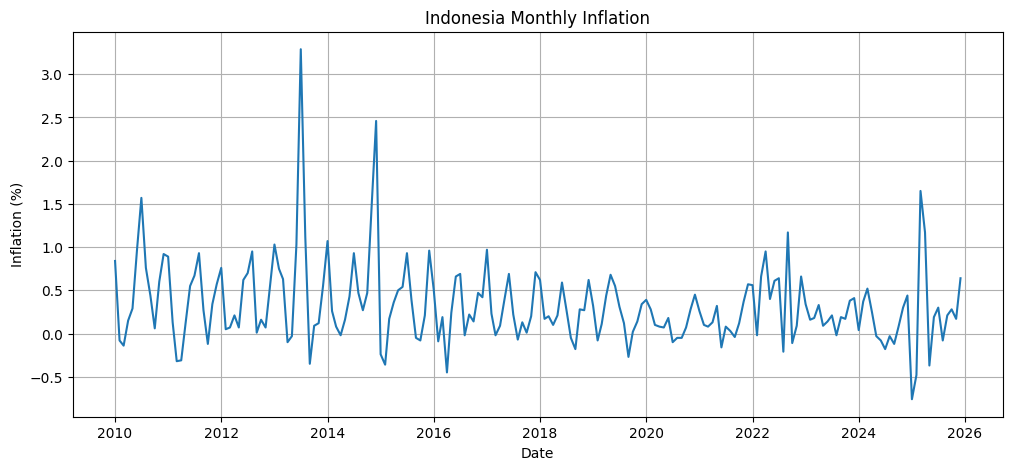

In [9]:
# Visualisasi perkembangan inflasi bulanan Indonesia

plt.figure(figsize=(12, 5))
plt.plot(master_df["date"], master_df["inflation"])
plt.title("Indonesia Monthly Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.grid(True)
plt.show()

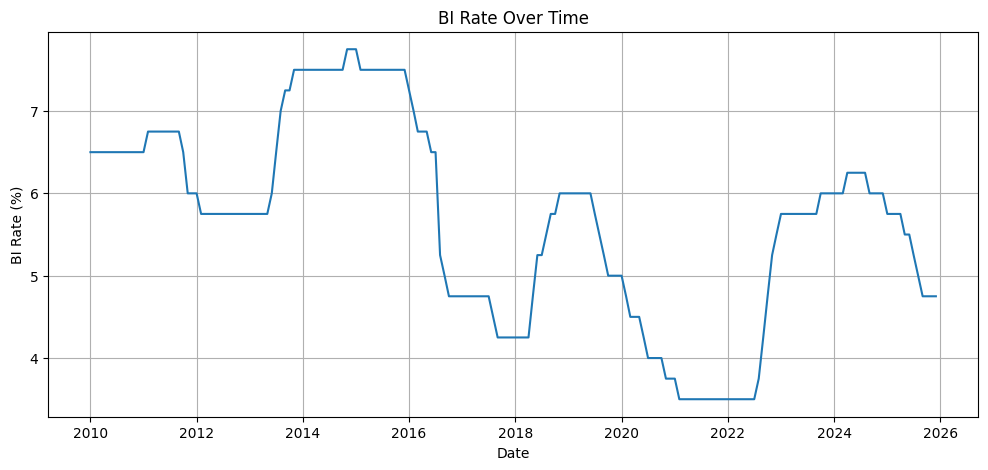

In [10]:
# Visualisasi BI Rate

plt.figure(figsize=(12, 5))
plt.plot(master_df["date"], master_df["bi_rate"])
plt.title("BI Rate Over Time")
plt.xlabel("Date")
plt.ylabel("BI Rate (%)")
plt.grid(True)
plt.show()

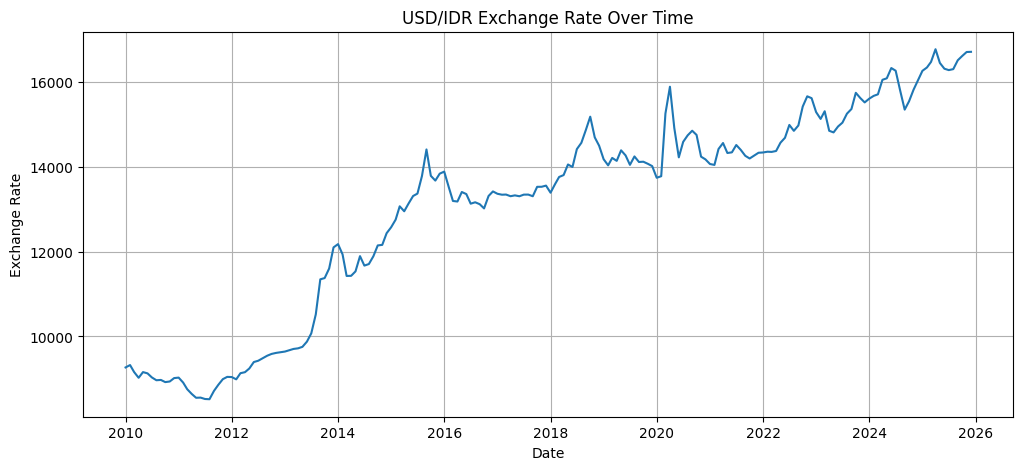

In [11]:
# Visualisasi Exchange Rate USD/IDR

plt.figure(figsize=(12, 5))
plt.plot(master_df["date"], master_df["exchange_rate"])
plt.title("USD/IDR Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.show()

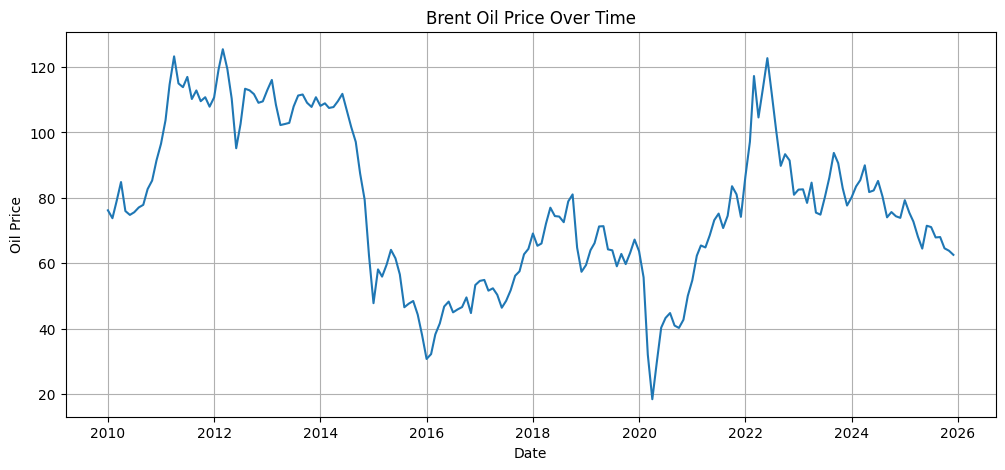

In [12]:
# Visualisasi Brent Oil Price

plt.figure(figsize=(12, 5))
plt.plot(master_df["date"], master_df["oil_price"])
plt.title("Brent Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.grid(True)
plt.show()

In [13]:
# Melihat korelasi antar variabel numerik

correlation_matrix = master_df[
    ["inflation", "bi_rate", "exchange_rate", "oil_price"]
].corr()

correlation_matrix

,inflation,bi_rate,exchange_rate,oil_price
inflation,1.000000,0.149230,-0.212819,0.148830
bi_rate,0.149230,1.000000,-0.398870,0.207684
exchange_rate,-0.212819,-0.398870,1.000000,-0.516374
oil_price,0.148830,0.207684,-0.516374,1.000000


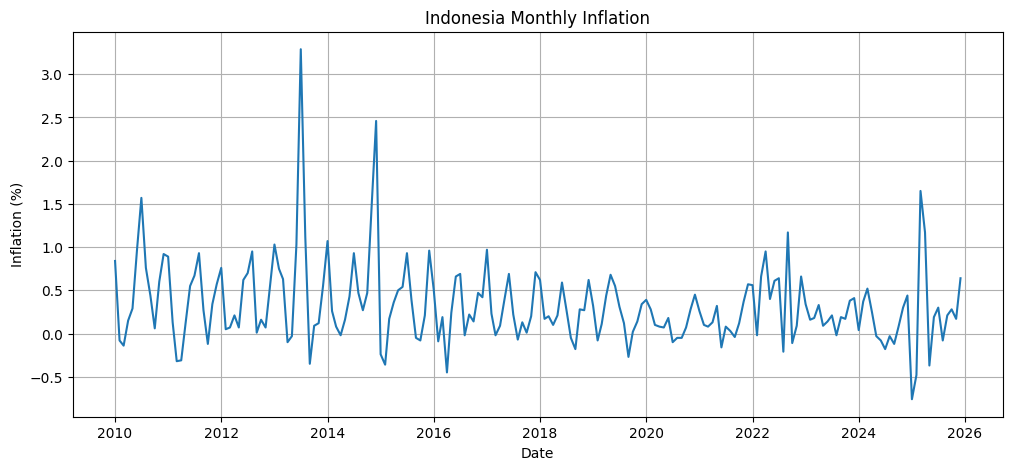

In [14]:
# Menyimpan grafik inflasi ke folder reports/figures

plt.figure(figsize=(12, 5))
plt.plot(master_df["date"], master_df["inflation"])
plt.title("Indonesia Monthly Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.grid(True)

plt.savefig(FIGURES_DIR / "indonesia_monthly_inflation.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Melihat statistik ringkas hanya untuk variabel numerik
# Kolom date tidak perlu ikut dianalisis secara statistik

master_df[
    ["inflation", "bi_rate", "exchange_rate", "oil_price"]
].describe()

,inflation,bi_rate,exchange_rate,oil_price
count,192.000000,192.000000,192.000000,192.000000
mean,0.323906,5.665365,13079.900052,77.557739
std,0.467354,1.220328,2414.084076,24.065249
min,-0.760000,3.500000,8521.260870,18.378500
25%,0.070000,4.750000,11507.250000,61.036556
50%,0.220000,5.750000,13778.503571,75.301955
75%,0.550000,6.500000,14763.906621,97.958341
max,3.290000,7.750000,16768.409091,125.445455


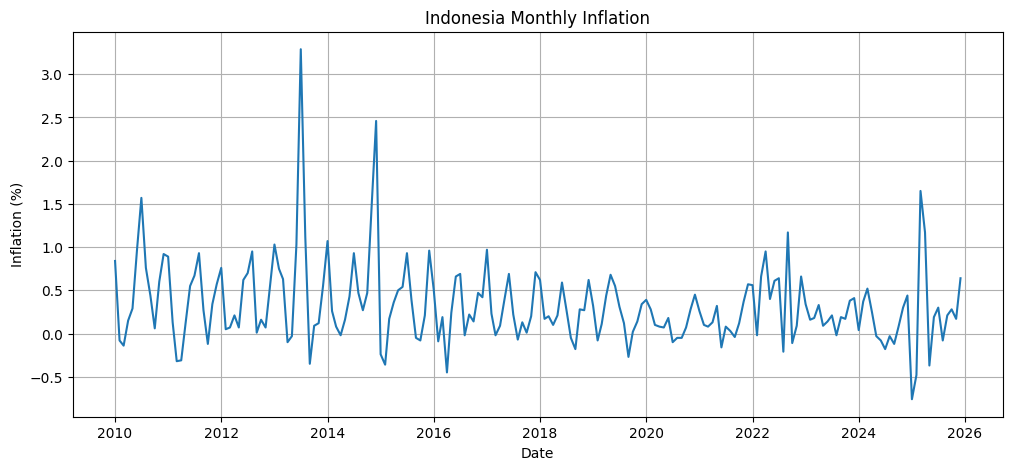

In [16]:
# Menyimpan grafik inflasi Indonesia

plt.figure(figsize=(12, 5))
plt.plot(master_df["date"], master_df["inflation"])
plt.title("Indonesia Monthly Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.grid(True)
plt.savefig(FIGURES_DIR / "indonesia_monthly_inflation.png", dpi=300, bbox_inches="tight")
plt.show()

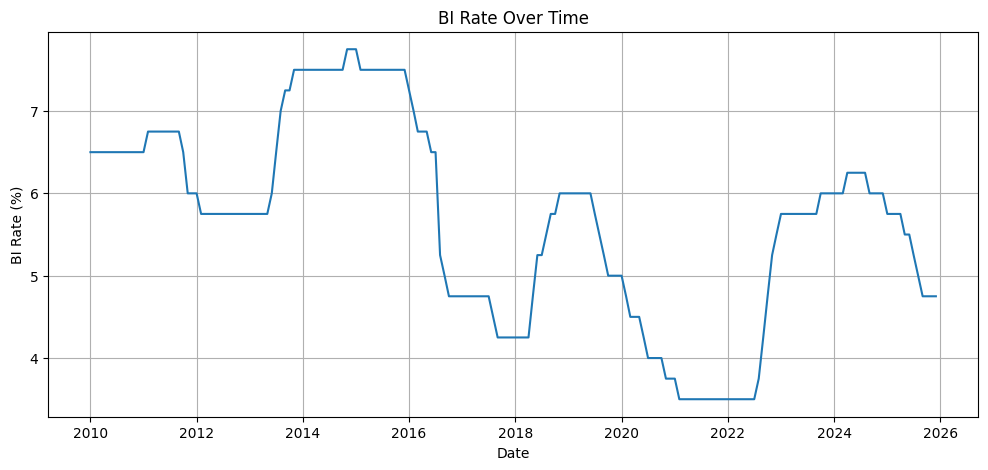

In [17]:
# Menyimpan grafik BI Rate

plt.figure(figsize=(12, 5))
plt.plot(master_df["date"], master_df["bi_rate"])
plt.title("BI Rate Over Time")
plt.xlabel("Date")
plt.ylabel("BI Rate (%)")
plt.grid(True)
plt.savefig(FIGURES_DIR / "bi_rate_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

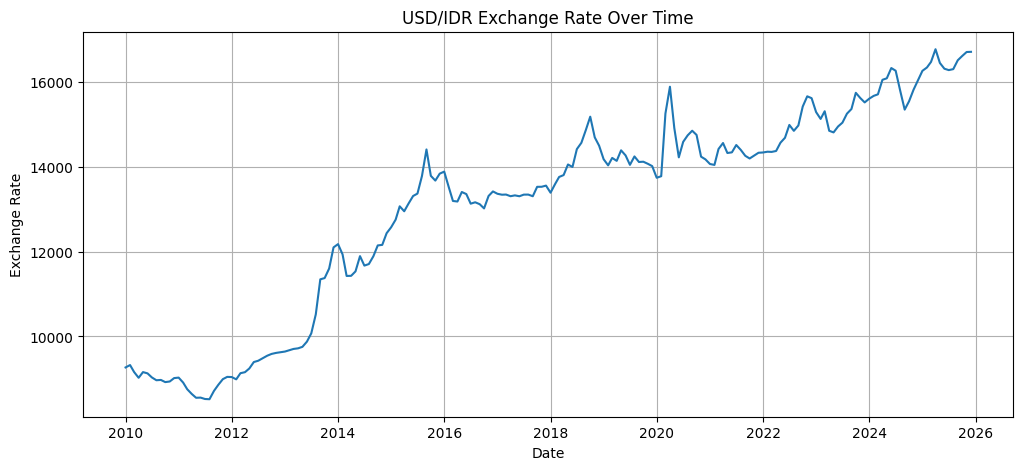

In [18]:
# Menyimpan grafik nilai tukar USD/IDR

plt.figure(figsize=(12, 5))
plt.plot(master_df["date"], master_df["exchange_rate"])
plt.title("USD/IDR Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.savefig(FIGURES_DIR / "exchange_rate_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

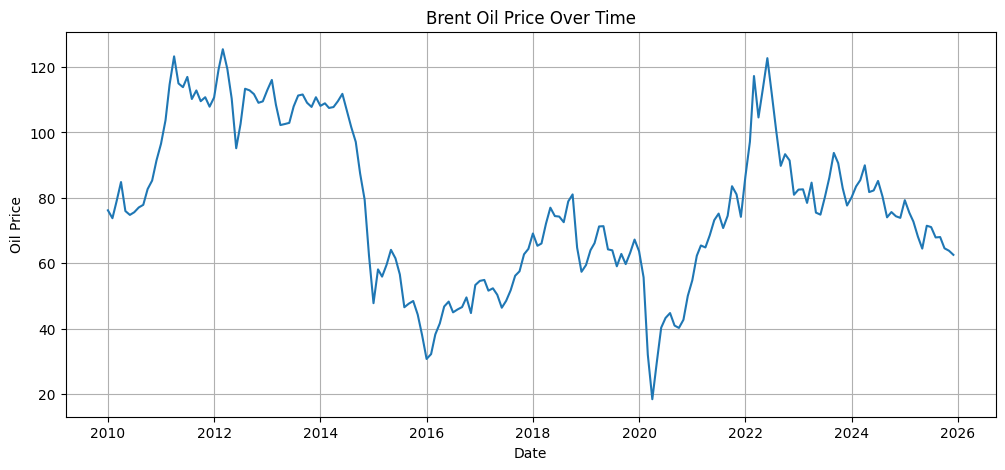

In [19]:
# Menyimpan grafik harga minyak Brent

plt.figure(figsize=(12, 5))
plt.plot(master_df["date"], master_df["oil_price"])
plt.title("Brent Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.grid(True)
plt.savefig(FIGURES_DIR / "brent_oil_price_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# Membuat correlation matrix antar variabel numerik

correlation_matrix = master_df[
    ["inflation", "bi_rate", "exchange_rate", "oil_price"]
].corr()

correlation_matrix

,inflation,bi_rate,exchange_rate,oil_price
inflation,1.000000,0.149230,-0.212819,0.148830
bi_rate,0.149230,1.000000,-0.398870,0.207684
exchange_rate,-0.212819,-0.398870,1.000000,-0.516374
oil_price,0.148830,0.207684,-0.516374,1.000000


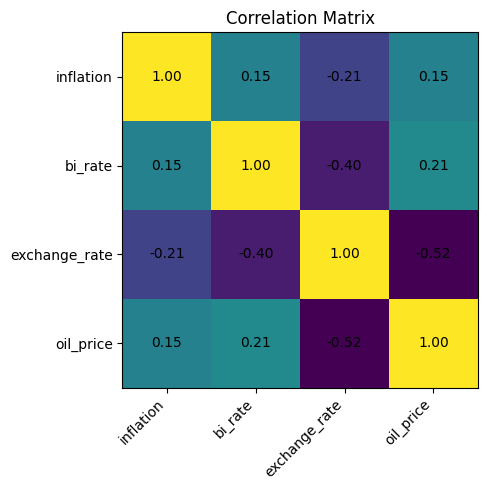

In [21]:
# Menyimpan correlation matrix sebagai gambar

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(correlation_matrix)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.columns)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# Mengecek file gambar yang sudah tersimpan di folder reports/figures

list(FIGURES_DIR.glob("*.png"))

[WindowsPath('c:/Users/Project/skripsi/inflation-forecast-final/reports/figures/bi_rate_over_time.png'),
 WindowsPath('c:/Users/Project/skripsi/inflation-forecast-final/reports/figures/brent_oil_price_over_time.png'),
 WindowsPath('c:/Users/Project/skripsi/inflation-forecast-final/reports/figures/correlation_matrix.png'),
 WindowsPath('c:/Users/Project/skripsi/inflation-forecast-final/reports/figures/exchange_rate_over_time.png'),
 WindowsPath('c:/Users/Project/skripsi/inflation-forecast-final/reports/figures/indonesia_monthly_inflation.png')]